# SBI Tutorial: infer SN 1993J bolometric parameters

This notebook shows an end-to-end Simulation-Based Inference (SBI) workflow using the real bolometric dataset in `examples/data/sn1993j_lbol.txt`.

The goal is to:
1. load the observed bolometric light curve,
2. train an SBI posterior with `tf.sbi.train_sbi()`,
3. infer physical parameters from the observed data with `tf.sbi.infer_sbi()`,
4. compare the inferred median model against the observations.

To keep the tutorial runnable on a laptop, the training configuration below is intentionally modest. For research use, increase `n_simulations`, `max_num_epochs`, and possibly the number of free parameters.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for cand in (cwd, cwd.parent):
        if (cand / "transfit").is_dir():
            return cand
    raise RuntimeError("Could not locate the local TransFit repository root.")


REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

for name in list(sys.modules):
    if name == "transfit" or name.startswith("transfit."):
        del sys.modules[name]

import transfit as tf

warnings.filterwarnings(
    "ignore",
    message="Using a user-supplied explicit distance that differs from the Planck15 luminosity distance implied by z by more than 5%.*",
    category=UserWarning,
)

plt.style.use("default")
plt.rcParams["axes.grid"] = False
np.random.seed(42)
torch.manual_seed(42)

DATA_DIR = REPO_ROOT / "examples" / "data"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using transfit from:", Path(tf.__file__).resolve())
print("Data directory:", DATA_DIR)
print("Torch:", torch.__version__)
print("Device:", DEVICE)


Using transfit from: /mnt/nas_nanhu/default/gaoyuan/git/TransFit/transfit/__init__.py
Data directory: /mnt/nas_nanhu/default/gaoyuan/git/TransFit/examples/data
Torch: 2.5.1+cu121
Device: cuda


## 1. Load the SN 1993J bolometric observations

The example file stores observer-frame times, bolometric luminosities, and luminosity errors.
For this SBI workflow, keep the published observer-frame times directly instead of rebasing them to day 0. That way the simulator is trained on the same cadence support that will be queried during inference.


Loaded 89 bolometric observations
Time span: 3.70 to 115.70 days


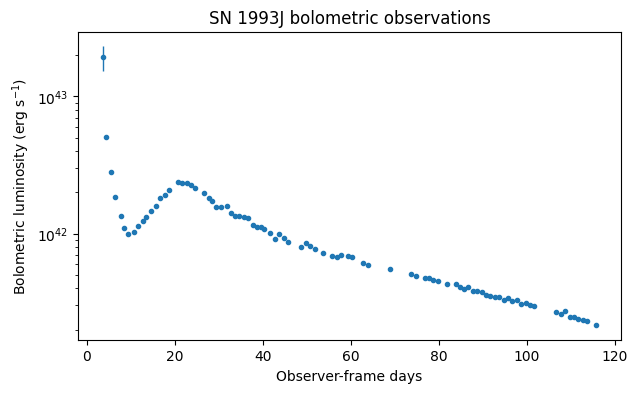

In [2]:
arr = np.loadtxt(DATA_DIR / "sn1993j_lbol.txt")

t_days = arr[:, 0]
Lbol = arr[:, 1]
Lbol_err = arr[:, 2]
log10_Lbol = np.log10(Lbol)

data_bol = tf.BolometricData(
    t_days=t_days,
    y=Lbol,
    yerr=Lbol_err,
)

print(f"Loaded {len(data_bol.t_days)} bolometric observations")
print(f"Time span: {data_bol.t_days.min():.2f} to {data_bol.t_days.max():.2f} days")

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(data_bol.t_days, data_bol.y, yerr=data_bol.yerr, fmt="o", ms=3, lw=1)
ax.set_yscale("log")
ax.set_xlabel("Observer-frame days")
ax.set_ylabel("Bolometric luminosity (erg s$^{-1}$)")
ax.set_title("SN 1993J bolometric observations")
plt.show()


## 2. Define the SBI training problem

To keep training fast and stable, this tutorial infers three parameters (`M_ej`, `v_ej`, `M_Ni`) and fixes the rest of the nickel-model parameters.

The cadence template is set to the observed SN 1993J sampling itself, so the simulator learns the same observation pattern that we later query during inference.


In [ ]:
z = 0.001728

priors = {
    "M_ej": (0.8, 6.0),
    "v_ej": (0.3, 2.0),
    "M_Ni": (0.01, 0.4),
}

fixed = {
    "E_Th_in": 0.0,
    "R_0": 120.0,
    "x_Ni": 0.2,
    "kappa": 0.12,
    "kappa_gamma": 0.03,
    "T_floor": 4500.0,
    "t_shift": 0.0,
}

cadence_templates = [{"t_days": data_bol.t_days.copy()}]

training_config = {
    "n_simulations": 5000,
    "hidden_features": 64,
    "num_transforms": 3,
    "training_batch_size": 128,
    "max_num_epochs": 1000,
    "learning_rate": 1e-4,  # Add this line - adjust the value as needed
    "show_progress": True,
    "device": DEVICE,
    "Nx": 20,
    "Ny": 50,
    "t_max_days": float(data_bol.t_days.max() + 5.0),
    "seed": 42,
}

training_config


{'n_simulations': 5000,
 'hidden_features': 64,
 'num_transforms': 3,
 'training_batch_size': 128,
 'max_num_epochs': 1000,
 'learning_rate': 0.0001,
 'show_progress': True,
 'device': 'cuda',
 'Nx': 20,
 'Ny': 50,
 't_max_days': 120.7,
 'seed': 42}

## 3. Train the SBI posterior

This uses `mode="bolometric"`, so no multiband filter context is needed.
The trained object is an `SBIPosterior`, which can later be sampled directly for any observation on the same public API conventions.


In [17]:
posterior = tf.sbi.train_sbi(
    model="nickel",
    mode="bolometric",
    z=z,
    priors=priors,
    fixed=fixed,
    cadence_templates=cadence_templates,
    **training_config,
)

print(type(posterior).__name__)
print("Sampled parameters:", posterior.param_names)
print("Posterior device:", posterior.device)
print("Stored metadata keys:", sorted(posterior.meta.keys()))


Simulating: 100%|██████████| 10/10 [00:00<00:00, 20.35chunk/s]


 Neural network successfully converged after 51 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 51
        Best validation performance: 1.7070
        -------------------------
        
SBIPosterior
Sampled parameters: ['M_ej', 'v_ej', 'M_Ni']
Posterior device: cuda:0
Stored metadata keys: ['Nx', 'Ny', 'bounds_samp', 'device', 'distance_modulus', 'filters', 'fixed', 'mag_system', 'mode', 'n_simulations', 'n_valid', 'names_all', 't_max_days', 't_range', 'x_event_shape', 'y_kind', 'z']


## 4. Infer physical parameters from the observation data

For bolometric SBI, the simulator is trained on `log10(L_bol)`, so the observed luminosities must be converted to `log10` before calling `infer_sbi()`.

`tf.sbi.infer_sbi()` then returns posterior samples together with quick summaries such as the posterior median and a simple MAP estimate.


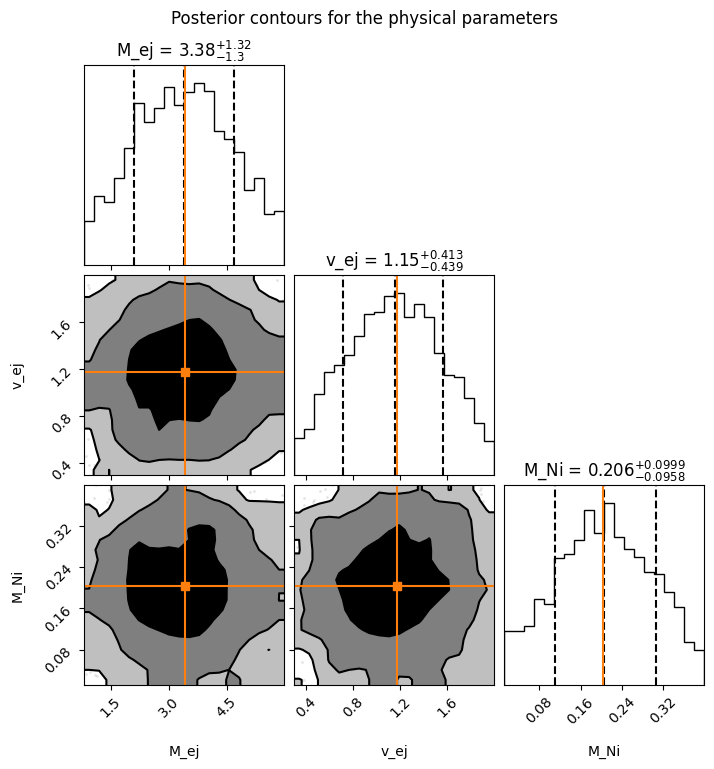

,median,map,q16,q84
M_ej,3.423367,3.209663,2.087744,4.700844
v_ej,1.174795,1.145495,0.715200,1.566422
M_Ni,0.203684,0.206301,0.109872,0.305588


In [18]:
import corner

result = tf.sbi.infer_sbi(
    posterior,
    y_obs=log10_Lbol,
    t_days=data_bol.t_days,
    n_samples=2000,
    seed=123,
)

samples = pd.DataFrame(result["samples"], columns=result["param_names"])
summary = pd.DataFrame(
    {
        "median": pd.Series(result["median"]),
        "map": pd.Series(result["map"]),
        "q16": samples.quantile(0.16),
        "q84": samples.quantile(0.84),
    }
)

figure = corner.corner(
    samples.to_numpy(),
    labels=samples.columns.tolist(),
    truths=[result["median"][name] for name in samples.columns],
    truth_color="tab:orange",
    show_titles=True,
    title_fmt=".3g",
    quantiles=[0.16, 0.5, 0.84],
    plot_contours=True,
    fill_contours=True,
    levels=(0.393, 0.865, 0.989),
    smooth=1.0,
)
figure.suptitle("Posterior contours for the physical parameters", y=1.02)
plt.show()

summary

## 5. Compare the inferred median model to the observations

The inferred median parameters can be passed back into the normal forward-model helpers. This is a useful sanity check that the posterior is learning the observed light-curve shape.


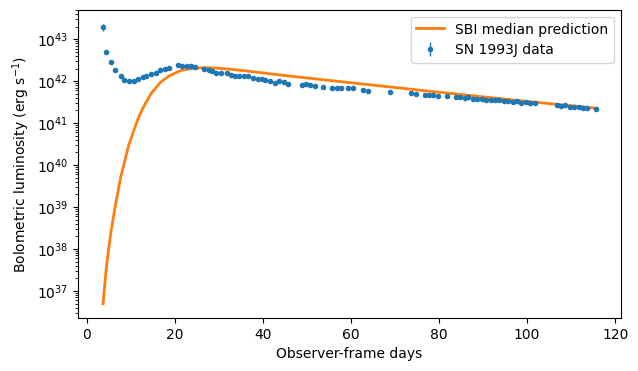

In [12]:
median_params = {**fixed, **result["median"]}

y_median = tf.predict_bol(
    model="nickel",
    params=median_params,
    z=z,
    t_days=data_bol.t_days,
    Nx=training_config["Nx"],
    Ny=training_config["Ny"],
    t_max_days=training_config["t_max_days"],
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(data_bol.t_days, data_bol.y, yerr=data_bol.yerr, fmt="o", ms=3, lw=1, label="SN 1993J data")
ax.plot(data_bol.t_days, y_median, lw=2, label="SBI median prediction")
ax.set_yscale("log")
ax.set_xlabel("Observer-frame days")
ax.set_ylabel("Bolometric luminosity (erg s$^{-1}$)")
ax.legend()
plt.show()


## 6. Save and reload the trained SBI posterior

Reloading lets you skip retraining when you want to reuse the same amortized posterior later.


In [13]:
posterior_path = Path("sn1993j_nickel_sbi.pt")

tf.sbi.save_posterior(posterior, posterior_path)
reloaded = tf.sbi.load_posterior(posterior_path, trusted=True)

quick_check = tf.sbi.infer_sbi(
    reloaded,
    y_obs=log10_Lbol,
    t_days=data_bol.t_days,
    n_samples=200,
    seed=123,
)

print("Saved posterior to:", posterior_path.resolve())
print("Reloaded posterior median:", quick_check["median"])


Saved posterior to: /mnt/nas_nanhu/default/gaoyuan/git/TransFit/examples/sn1993j_nickel_sbi.pt
Reloaded posterior median: {'M_ej': 3.3238760232925415, 'v_ej': 1.1763601899147034, 'M_Ni': 0.19610493630170822}
